In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from collections import Counter

import shutil
from sklearn.model_selection import train_test_split
import cv2
from collections import Counter

Cellule 2 — Définir les chemins

In [7]:
# Adapter selon ton os.getcwd()
OCT_PATH  = "../data/OCT"
XRAY_PATH = "../data/chest_xray"

Cellule 3 — Nettoyage : Vérifier images corrompues

In [3]:
def verifier_images(base_path):
    corrompues = []
    total      = 0

    for split in ['train', 'test']:
        split_path = os.path.join(base_path, split)
        for classe in os.listdir(split_path):
            classe_path = os.path.join(split_path, classe)
            if not os.path.isdir(classe_path):
                continue
            for img_file in os.listdir(classe_path):
                img_path = os.path.join(classe_path, img_file)
                total += 1
                try:
                    img = Image.open(img_path)
                    img.verify()
                except Exception as e:
                    corrompues.append(img_path)

    print(f"Total images vérifiées : {total}")
    print(f"Images corrompues      : {len(corrompues)}")
    if corrompues:
        for c in corrompues:
            print(f"  ❌ {c}")
    else:
        print("✅ Aucune image corrompue !")

    return corrompues

print("=== OCT ===")
corrompues_oct  = verifier_images(OCT_PATH)

print("\n=== X-RAY ===")
corrompues_xray = verifier_images(XRAY_PATH)

=== OCT ===
Total images vérifiées : 84484
Images corrompues      : 0
✅ Aucune image corrompue !

=== X-RAY ===
Total images vérifiées : 5856
Images corrompues      : 0
✅ Aucune image corrompue !


verification des doublons : Code avec Hash MD5

In [8]:
import hashlib

def verifier_doublons_hash(base_path):
    hash_dict = {}  # hash → liste de chemins
    doublons  = []
    total     = 0

    for split in ['train', 'test']:
        split_path = os.path.join(base_path, split)
        for classe in os.listdir(split_path):
            classe_path = os.path.join(split_path, classe)
            if not os.path.isdir(classe_path):
                continue
            for img_file in os.listdir(classe_path):
                img_path = os.path.join(classe_path, img_file)
                total += 1

                # Calculer le hash MD5 du fichier
                with open(img_path, 'rb') as f:
                    hash_md5 = hashlib.md5(f.read()).hexdigest()

                if hash_md5 in hash_dict:
                    doublons.append({
                        'original'  : hash_dict[hash_md5],
                        'doublon'   : img_path,
                        'hash'      : hash_md5
                    })
                else:
                    hash_dict[hash_md5] = img_path

    print(f"Total images analysées : {total}")
    print(f"Doublons trouvés       : {len(doublons)}")

    if doublons:
        print("\nExemples de doublons :")
        for d in doublons[:3]:
            print(f"  Hash     : {d['hash']}")
            print(f"  Original : {d['original']}")
            print(f"  Doublon  : {d['doublon']}")
            print()
    else:
        print("✅ Aucun doublon détecté !")

    return doublons

print("=== OCT ===")
doublons_oct  = verifier_doublons_hash(OCT_PATH)

print("\n=== X-RAY ===")
doublons_xray = verifier_doublons_hash(XRAY_PATH)

=== OCT ===
Total images analysées : 84484
Doublons trouvés       : 7582

Exemples de doublons :
  Hash     : 8e96347ce7da5ff54075653d5069d04d
  Original : ../data/OCT\train\CNV\CNV-1016042-101.jpeg
  Doublon  : ../data/OCT\train\CNV\CNV-1016042-102.jpeg

  Hash     : 8e96347ce7da5ff54075653d5069d04d
  Original : ../data/OCT\train\CNV\CNV-1016042-101.jpeg
  Doublon  : ../data/OCT\train\CNV\CNV-1016042-103.jpeg

  Hash     : e4a5b7348a21c514a8106d18f6fbd572
  Original : ../data/OCT\train\CNV\CNV-1016042-104.jpeg
  Doublon  : ../data/OCT\train\CNV\CNV-1016042-105.jpeg


=== X-RAY ===
Total images analysées : 5856
Doublons trouvés       : 32

Exemples de doublons :
  Hash     : dcc3ab0eaf19ff80af9d3d254b340da5
  Original : ../data/chest_xray\train\NORMAL\NORMAL2-IM-0587-0001-0001.jpeg
  Doublon  : ../data/chest_xray\train\NORMAL\NORMAL2-IM-0587-0001-0002.jpeg

  Hash     : edbf5c2810fce5b00722716ab730e577
  Original : ../data/chest_xray\train\PNEUMONIA\person1159_virus_1944.jpeg
  Doublon

affecher des doublons

C:\Users\PC\AppData\Local\Temp\ipykernel_6420\2579663829.py:40: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\PC\AppData\Local\Temp\ipykernel_6420\2579663829.py:40: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\PC\AppData\Local\Temp\ipykernel_6420\2579663829.py:41: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(f"../results/doublons_{titre}.png")
C:\Users\PC\AppData\Local\Temp\ipykernel_6420\2579663829.py:41: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(f"../results/doublons_{titre}.png")
d:\Disque_C\users\pc\anaconda3\envs\monenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Disque_C\users\pc\anaconda3\envs\monenv\Lib\site-pa

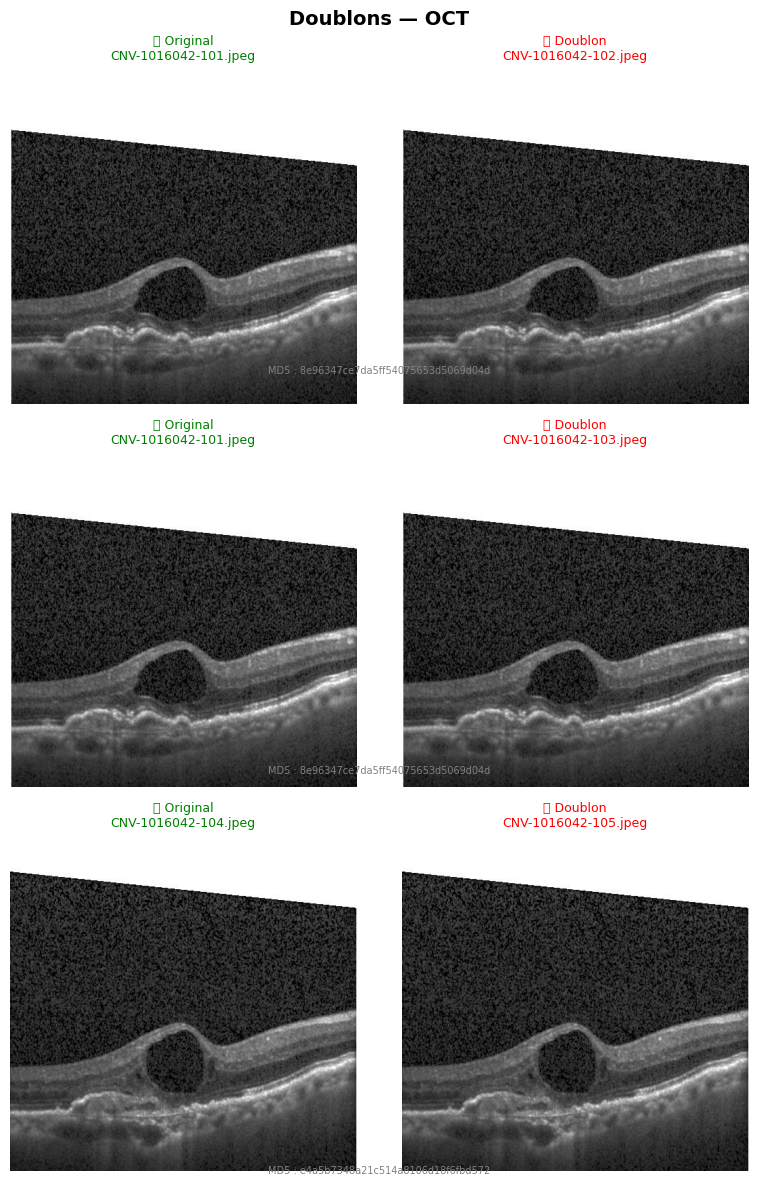


  OCT — 7582 doublon(s) détecté(s)

  Paire 1 :
    Original : ../data/OCT\train\CNV\CNV-1016042-101.jpeg
    Doublon  : ../data/OCT\train\CNV\CNV-1016042-102.jpeg
    Hash MD5 : 8e96347ce7da5ff54075653d5069d04d

  Paire 2 :
    Original : ../data/OCT\train\CNV\CNV-1016042-101.jpeg
    Doublon  : ../data/OCT\train\CNV\CNV-1016042-103.jpeg
    Hash MD5 : 8e96347ce7da5ff54075653d5069d04d

  Paire 3 :
    Original : ../data/OCT\train\CNV\CNV-1016042-104.jpeg
    Doublon  : ../data/OCT\train\CNV\CNV-1016042-105.jpeg
    Hash MD5 : e4a5b7348a21c514a8106d18f6fbd572


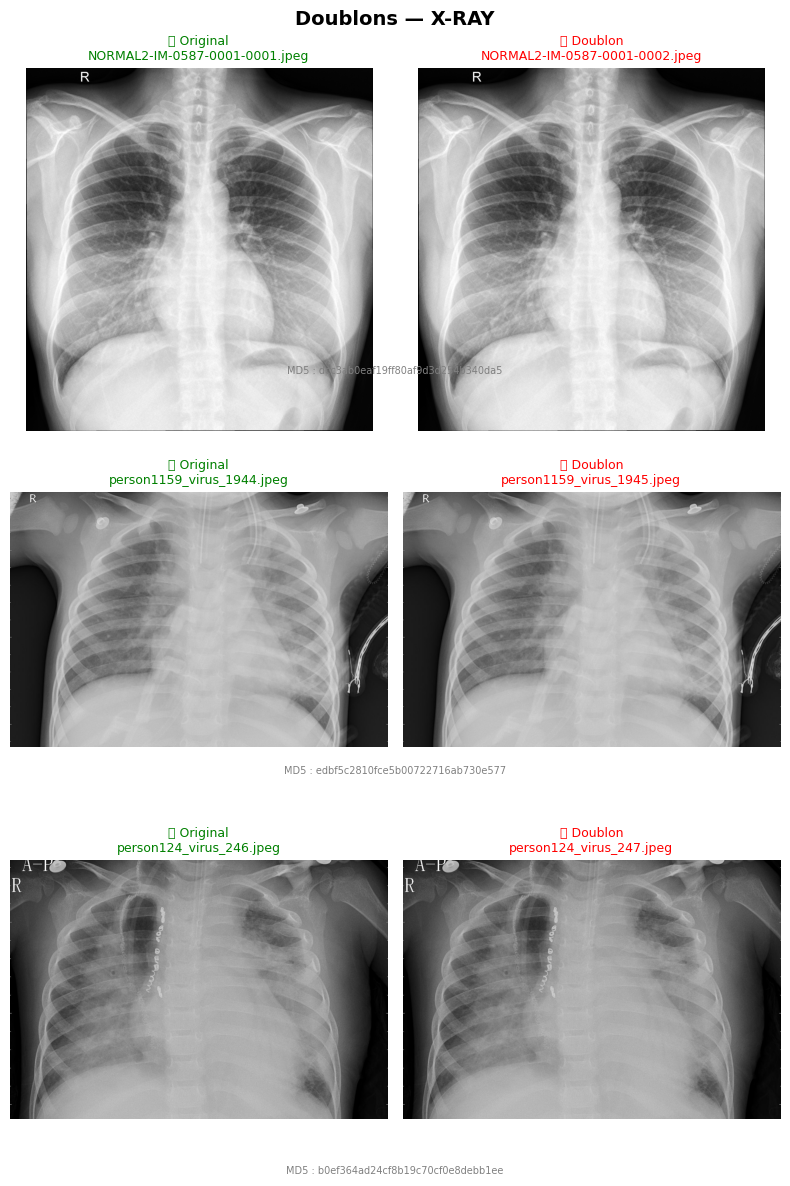


  X-RAY — 32 doublon(s) détecté(s)

  Paire 1 :
    Original : ../data/chest_xray\train\NORMAL\NORMAL2-IM-0587-0001-0001.jpeg
    Doublon  : ../data/chest_xray\train\NORMAL\NORMAL2-IM-0587-0001-0002.jpeg
    Hash MD5 : dcc3ab0eaf19ff80af9d3d254b340da5

  Paire 2 :
    Original : ../data/chest_xray\train\PNEUMONIA\person1159_virus_1944.jpeg
    Doublon  : ../data/chest_xray\train\PNEUMONIA\person1159_virus_1945.jpeg
    Hash MD5 : edbf5c2810fce5b00722716ab730e577

  Paire 3 :
    Original : ../data/chest_xray\train\PNEUMONIA\person124_virus_246.jpeg
    Doublon  : ../data/chest_xray\train\PNEUMONIA\person124_virus_247.jpeg
    Hash MD5 : b0ef364ad24cf8b19c70cf0e8debb1ee


In [9]:
def afficher_exemple_doublon(doublons, titre, n=3):
    if not doublons:
        print(f"✅ Aucun doublon dans {titre}")
        return

    # Prendre les n premiers doublons
    exemples = doublons[:n]
    fig, axes = plt.subplots(n, 2, figsize=(8, n * 4))
    fig.suptitle(f"Doublons — {titre}", fontsize=14, fontweight='bold')

    # Si un seul doublon, axes n'est pas 2D → forcer 2D
    if n == 1:
        axes = [axes]

    for i, d in enumerate(exemples):
        img_orig    = Image.open(d['original']).convert('RGB')
        img_doublon = Image.open(d['doublon']).convert('RGB')

        # ── Original ──────────────────────────────────────────────────────────
        axes[i][0].imshow(img_orig, cmap='gray')
        axes[i][0].set_title(
            f"✅ Original\n{os.path.basename(d['original'])}",
            fontsize=9, color='green'
        )
        axes[i][0].axis('off')

        # ── Doublon ───────────────────────────────────────────────────────────
        axes[i][1].imshow(img_doublon, cmap='gray')
        axes[i][1].set_title(
            f"❌ Doublon\n{os.path.basename(d['doublon'])}",
            fontsize=9, color='red'
        )
        axes[i][1].axis('off')

        # ── Hash en bas de chaque paire ───────────────────────────────────────
        fig.text(0.5, 1 - (i + 1) / n + 0.01,
                 f"MD5 : {d['hash']}",
                 ha='center', fontsize=7, color='gray')

    plt.tight_layout()
    plt.savefig(f"../results/doublons_{titre}.png")
    plt.show()

    # ── Résumé texte ──────────────────────────────────────────────────────────
    print(f"\n{'='*50}")
    print(f"  {titre} — {len(doublons)} doublon(s) détecté(s)")
    print(f"{'='*50}")
    for i, d in enumerate(exemples):
        print(f"\n  Paire {i+1} :")
        print(f"    Original : {d['original']}")
        print(f"    Doublon  : {d['doublon']}")
        print(f"    Hash MD5 : {d['hash']}")

# ── Appel ─────────────────────────────────────────────────────────────────────
afficher_exemple_doublon(doublons_oct,  "OCT",   n=3)
afficher_exemple_doublon(doublons_xray, "X-RAY", n=3)

Si des doublons sont trouvés → les supprimer

In [5]:
def supprimer_doublons(doublons):
    if not doublons:
        print("✅ Rien à supprimer")
        return

    for d in doublons:
        if os.path.exists(d['doublon']):
            os.remove(d['doublon'])
            print(f"🗑️  Supprimé : {d['doublon']}")

    print(f"\n✅ {len(doublons)} doublon(s) supprimé(s)")

supprimer_doublons(doublons_oct)
supprimer_doublons(doublons_xray)

🗑️  Supprimé : ../data/OCT\train\CNV\CNV-1016042-102.jpeg
🗑️  Supprimé : ../data/OCT\train\CNV\CNV-1016042-103.jpeg
🗑️  Supprimé : ../data/OCT\train\CNV\CNV-1016042-105.jpeg
🗑️  Supprimé : ../data/OCT\train\CNV\CNV-1016042-106.jpeg
🗑️  Supprimé : ../data/OCT\train\CNV\CNV-1016042-108.jpeg
🗑️  Supprimé : ../data/OCT\train\CNV\CNV-1016042-109.jpeg
🗑️  Supprimé : ../data/OCT\train\CNV\CNV-1016042-11.jpeg
🗑️  Supprimé : ../data/OCT\train\CNV\CNV-1016042-111.jpeg
🗑️  Supprimé : ../data/OCT\train\CNV\CNV-1016042-112.jpeg
🗑️  Supprimé : ../data/OCT\train\CNV\CNV-1016042-114.jpeg
🗑️  Supprimé : ../data/OCT\train\CNV\CNV-1016042-116.jpeg
🗑️  Supprimé : ../data/OCT\train\CNV\CNV-1016042-117.jpeg
🗑️  Supprimé : ../data/OCT\train\CNV\CNV-1016042-119.jpeg
🗑️  Supprimé : ../data/OCT\train\CNV\CNV-1016042-12.jpeg
🗑️  Supprimé : ../data/OCT\train\CNV\CNV-1016042-120.jpeg
🗑️  Supprimé : ../data/OCT\train\CNV\CNV-1016042-122.jpeg
🗑️  Supprimé : ../data/OCT\train\CNV\CNV-1016042-123.jpeg
🗑️  Supprimé : .

taille des données apres nettoyage 

In [6]:
def compter_classes(base_path):
    resultats = {}
    for split in ['train', 'test']:
        split_path = os.path.join(base_path, split)
        resultats[split] = {}
        for classe in os.listdir(split_path):
            classe_path = os.path.join(split_path, classe)
            if os.path.isdir(classe_path):
                nb = len(os.listdir(classe_path))
                resultats[split][classe] = nb
    return resultats

# Chemins corrigés
oct_stats  = compter_classes("../data/OCT")
xray_stats = compter_classes("../data/chest_xray")

print("=== OCT ===")
for split, classes in oct_stats.items():
    print(f"\n{split.upper()} :")
    for classe, nb in classes.items():
        print(f"  {classe} : {nb} images")

print("\n=== CHEST X-RAY ===")
for split, classes in xray_stats.items():
    print(f"\n{split.upper()} :")
    for classe, nb in classes.items():
        print(f"  {classe} : {nb} images")

=== OCT ===

TRAIN :
  CNV : 31635 images
  DME : 10918 images
  DRUSEN : 7830 images
  NORMAL : 26114 images

TEST :
  CNV : 14 images
  DME : 209 images
  DRUSEN : 9 images
  NORMAL : 173 images

=== CHEST X-RAY ===

TRAIN :
  NORMAL : 1348 images
  PNEUMONIA : 3858 images

TEST :
  NORMAL : 231 images
  PNEUMONIA : 387 images


Nettoyage : Détecter outliers

In [ ]:
def detecter_outliers(base_path, seuil_noir=10, seuil_blanc=245):
    outliers = []

    for split in ['train', 'test']:
        split_path = os.path.join(base_path, split)
        for classe in os.listdir(split_path):
            classe_path = os.path.join(split_path, classe)
            if not os.path.isdir(classe_path):
                continue
            for img_file in os.listdir(classe_path):
                img_path = os.path.join(classe_path, img_file)
                try:
                    img      = np.array(Image.open(img_path).convert('L'))
                    moyenne  = img.mean() # moyenne = luminosité globale de l’image
                    if moyenne < seuil_noir or moyenne > seuil_blanc:
                        outliers.append((img_path, round(moyenne, 2)))
                except:
                    pass

    print(f"Outliers détectés : {len(outliers)}")
    for path, moy in outliers[:5]:  # afficher les 5 premiers
        print(f"  ⚠️  moyenne={moy} → {path}")

    if not outliers:
        print("✅ Aucun outlier détecté !")

    return outliers

print("=== OCT ===")
outliers_oct  = detecter_outliers(OCT_PATH)

print("\n=== X-RAY ===")
outliers_xray = detecter_outliers(XRAY_PATH)


=== OCT ===
Outliers détectés : 0
✅ Aucun outlier détecté !

=== X-RAY ===
Outliers détectés : 0
✅ Aucun outlier détecté !


Analyser tailles des images

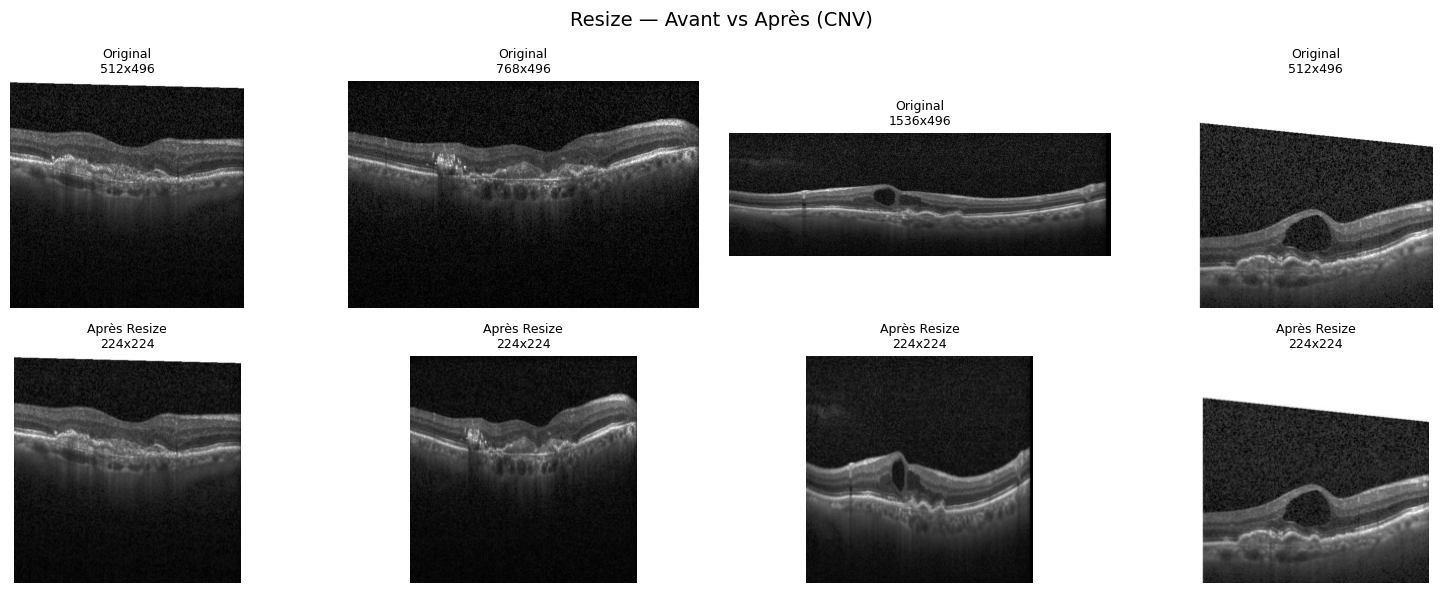

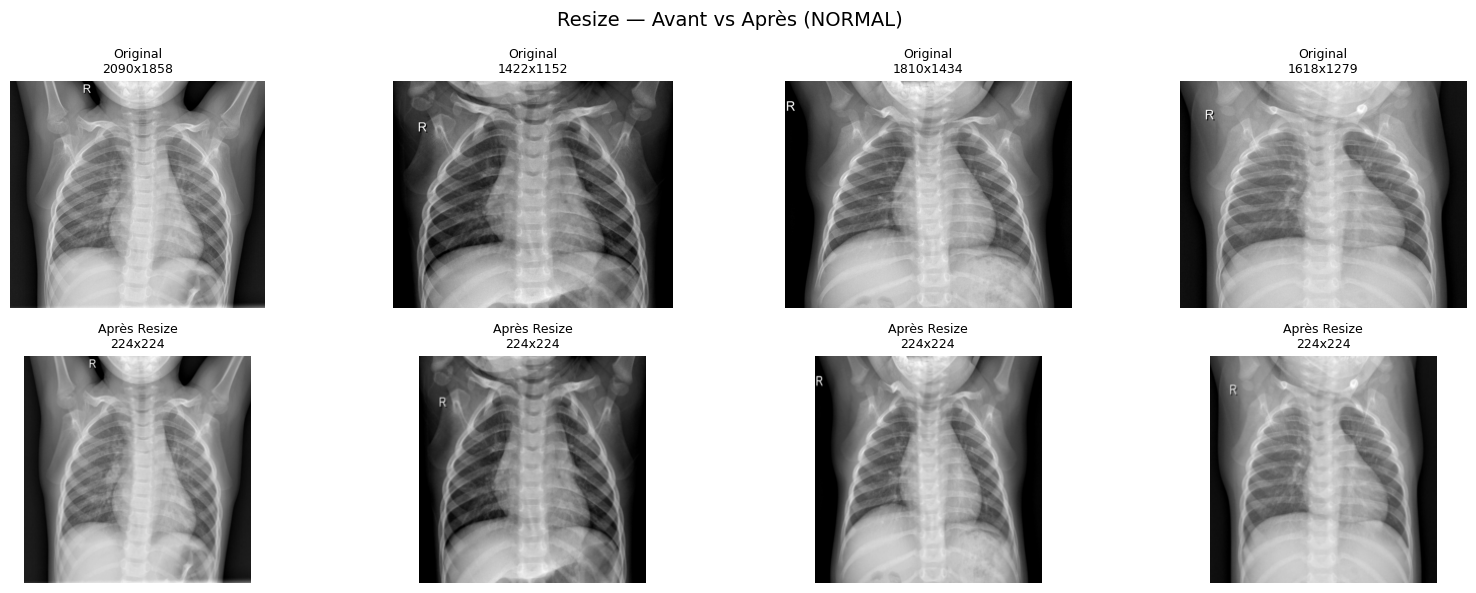

✅ Resize : toutes les images → 224x224 px


In [8]:
IMG_SIZE = 224

# Transform UNIQUEMENT resize — pour vérifier avant/après
resize_only = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),   # juste pour pouvoir afficher
])

# ── Vérification visuelle avant/après resize ──────────────────────────────────
def verifier_resize(base_path, classe, n=4):
    classe_path = os.path.join(base_path, "train", classe)
    images_files = os.listdir(classe_path)[:n]

    fig, axes = plt.subplots(2, n, figsize=(n * 4, 6))
    fig.suptitle(f"Resize — Avant vs Après ({classe})", fontsize=14)

    for j, img_file in enumerate(images_files):
        img_orig = Image.open(os.path.join(classe_path, img_file)).convert('RGB')
        img_resized = resize_only(img_orig)

        # Avant
        axes[0][j].imshow(img_orig, cmap='gray')
        axes[0][j].set_title(f"Original\n{img_orig.size[0]}x{img_orig.size[1]}", fontsize=9)
        axes[0][j].axis('off')

        # Après
        axes[1][j].imshow(img_resized.permute(1, 2, 0).numpy())
        axes[1][j].set_title(f"Après Resize\n{IMG_SIZE}x{IMG_SIZE}", fontsize=9)
        axes[1][j].axis('off')

    plt.tight_layout()
    plt.savefig(f"../results/resize_verification_{classe}.png")
    plt.show()

# Tester sur une classe OCT et une X-Ray
verifier_resize(OCT_PATH,  "CNV")
verifier_resize(XRAY_PATH, "NORMAL")

print(f"✅ Resize : toutes les images → {IMG_SIZE}x{IMG_SIZE} px")

In [12]:
import json

# ── ImageFolder encode automatiquement les classes par ordre alphabétique ─────
# class2idx : nom classe → index
# idx2class : index → nom classe

oct_class2idx  = oct_train_raw.class_to_idx   # {'CNV':0, 'DME':1, 'DRUSEN':2, 'NORMAL':3}
oct_idx2class  = {v: k for k, v in oct_class2idx.items()}

xray_class2idx = xray_train_raw.class_to_idx  # {'NORMAL':0, 'PNEUMONIA':1}
xray_idx2class = {v: k for k, v in xray_class2idx.items()}

# ── Affichage ─────────────────────────────────────────────────────────────────
print("=" * 40)
print("  ENCODAGE OCT")
print("=" * 40)
for classe, idx in oct_class2idx.items():
    print(f"  {classe:10s}  →  label {idx}")

print("\n" + "=" * 40)
print("  ENCODAGE X-RAY")
print("=" * 40)
for classe, idx in xray_class2idx.items():
    print(f"  {classe:12s}  →  label {idx}")

# ── Sauvegarder ───────────────────────────────────────────────────────────────
with open("../results/oct_class_mapping.json",  "w") as f:
    json.dump(oct_class2idx, f, indent=2)
with open("../results/xray_class_mapping.json", "w") as f:
    json.dump(xray_class2idx, f, indent=2)

print("\n✅ Encodages sauvegardés !")

  ENCODAGE OCT
  CNV         →  label 0
  DME         →  label 1
  DRUSEN      →  label 2
  NORMAL      →  label 3

  ENCODAGE X-RAY
  NORMAL        →  label 0
  PNEUMONIA     →  label 1

✅ Encodages sauvegardés !


In [17]:
def assemble_pool(base_path):
    """
    Regroupe train/ + test/ originaux en une seule liste
    Retourne : liste de (chemin_image, label)
    """
    all_paths  = []
    all_labels = []

    for split in ['train', 'test']:
        split_path = os.path.join(base_path, split)
        for classe in sorted(os.listdir(split_path)):
            classe_path = os.path.join(split_path, classe)
            if not os.path.isdir(classe_path):
                continue
            for img_file in os.listdir(classe_path):
                img_path = os.path.join(classe_path, img_file)
                all_paths.append(img_path)
                all_labels.append(classe)

    print(f"Total images dans le pool : {len(all_paths)}")
    print(f"Distribution : {Counter(all_labels)}")
    return all_paths, all_labels

print("=== OCT ===")
oct_paths,  oct_labels  = assemble_pool(OCT_PATH)

print("\n=== X-RAY ===")
xray_paths, xray_labels = assemble_pool(XRAY_PATH)

=== OCT ===
Total images dans le pool : 76902
Distribution : Counter({'CNV': 31649, 'NORMAL': 26287, 'DME': 11127, 'DRUSEN': 7839})

=== X-RAY ===
Total images dans le pool : 5824
Distribution : Counter({'PNEUMONIA': 4245, 'NORMAL': 1579})


 Split stratifié 80/20 (train_raw + test)

In [18]:
def split_train_test(paths, labels, test_size=0.20, random_state=42):
    train_p, test_p, train_l, test_l = train_test_split(
        paths, labels,
        test_size=test_size,
        stratify=labels,
        random_state=random_state
    )

    print(f"Train raw : {len(train_p)} images")
    print(f"  {Counter(train_l)}")
    print(f"Test      : {len(test_p)} images")
    print(f"  {Counter(test_l)}")
    return train_p, test_p, train_l, test_l

print("=== OCT ===")
oct_train_raw_p,  oct_test_p, \
oct_train_raw_l,  oct_test_l  = split_train_test(oct_paths,  oct_labels)

print("\n=== X-RAY ===")
xray_train_raw_p, xray_test_p, \
xray_train_raw_l, xray_test_l = split_train_test(xray_paths, xray_labels)

=== OCT ===
Train raw : 61521 images
  Counter({'CNV': 25319, 'NORMAL': 21029, 'DME': 8902, 'DRUSEN': 6271})
Test      : 15381 images
  Counter({'CNV': 6330, 'NORMAL': 5258, 'DME': 2225, 'DRUSEN': 1568})

=== X-RAY ===
Train raw : 4659 images
  Counter({'PNEUMONIA': 3396, 'NORMAL': 1263})
Test      : 1165 images
  Counter({'PNEUMONIA': 849, 'NORMAL': 316})


Split train_raw en train + val (85/15)

In [19]:
def split_train_val(train_paths, train_labels, val_size=0.15, random_state=42):
    train_p, val_p, train_l, val_l = train_test_split(
        train_paths, train_labels,
        test_size=val_size,
        stratify=train_labels,
        random_state=random_state
    )

    print(f"Train final : {len(train_p)} images")
    print(f"  {Counter(train_l)}")
    print(f"Val         : {len(val_p)} images")
    print(f"  {Counter(val_l)}")
    return train_p, val_p, train_l, val_l

print("=== OCT ===")
oct_train_p, oct_val_p, \
oct_train_l, oct_val_l = split_train_val(oct_train_raw_p, oct_train_raw_l)

print("\n=== X-RAY ===")
xray_train_p, xray_val_p, \
xray_train_l, xray_val_l = split_train_val(xray_train_raw_p, xray_train_raw_l)

=== OCT ===
Train final : 52292 images
  Counter({'CNV': 21521, 'NORMAL': 17874, 'DME': 7567, 'DRUSEN': 5330})
Val         : 9229 images
  Counter({'CNV': 3798, 'NORMAL': 3155, 'DME': 1335, 'DRUSEN': 941})

=== X-RAY ===
Train final : 3960 images
  Counter({'PNEUMONIA': 2886, 'NORMAL': 1074})
Val         : 699 images
  Counter({'PNEUMONIA': 510, 'NORMAL': 189})


Sauvegarder les splits sur disque


In [20]:
def sauvegarder_split(paths, labels, output_dir):
    # Nettoyer le dossier si existe
    if os.path.exists(output_dir):
        shutil.rmtree(output_dir)

    for path, label in zip(paths, labels):
        dest_dir = os.path.join(output_dir, label)
        os.makedirs(dest_dir, exist_ok=True)
        shutil.copy2(path, os.path.join(dest_dir, os.path.basename(path)))

    print(f"✅ Sauvegardé : {output_dir}")
    for classe in sorted(os.listdir(output_dir)):
        nb = len(os.listdir(os.path.join(output_dir, classe)))
        print(f"  {classe} : {nb} images")

# ── OCT ───────────────────────────────────────────────────
print("=== OCT ===")
sauvegarder_split(oct_train_p, oct_train_l, "../data/OCT_clean/train")
print()
sauvegarder_split(oct_val_p,   oct_val_l,   "../data/OCT_clean/val")
print()
sauvegarder_split(oct_test_p,  oct_test_l,  "../data/OCT_clean/test")

# ── X-RAY ─────────────────────────────────────────────────
print("\n=== X-RAY ===")
sauvegarder_split(xray_train_p, xray_train_l, "../data/xray_clean/train")
print()
sauvegarder_split(xray_val_p,   xray_val_l,   "../data/xray_clean/val")
print()
sauvegarder_split(xray_test_p,  xray_test_l,  "../data/xray_clean/test")

=== OCT ===
✅ Sauvegardé : ../data/OCT_clean/train
  CNV : 21520 images
  DME : 7510 images
  DRUSEN : 5327 images
  NORMAL : 17801 images

✅ Sauvegardé : ../data/OCT_clean/val
  CNV : 3798 images
  DME : 1335 images
  DRUSEN : 941 images
  NORMAL : 3155 images

✅ Sauvegardé : ../data/OCT_clean/test
  CNV : 6330 images
  DME : 2219 images
  DRUSEN : 1568 images
  NORMAL : 5256 images

=== X-RAY ===
✅ Sauvegardé : ../data/xray_clean/train
  NORMAL : 1074 images
  PNEUMONIA : 2886 images

✅ Sauvegardé : ../data/xray_clean/val
  NORMAL : 189 images
  PNEUMONIA : 510 images

✅ Sauvegardé : ../data/xray_clean/test
  NORMAL : 316 images
  PNEUMONIA : 849 images


data augmentation 

1. calcule de l'objectif 


In [3]:
def calculer_objectif(train_dir, multiplicateur=1.5):
    """
    Objectif = classe majoritaire × multiplicateur
    Toutes les classes seront augmentées jusqu'à cet objectif
    """
    counter = {}
    for classe in sorted(os.listdir(train_dir)):
        classe_path = os.path.join(train_dir, classe)
        if os.path.isdir(classe_path):
            counter[classe] = len(os.listdir(classe_path))

    max_count = max(counter.values())
    objectif  = int(max_count * multiplicateur)

    print(f"Distribution actuelle :")
    for classe, nb in counter.items():
        ratio = objectif / nb
        print(f"  {classe:12} : {nb:6} images → objectif {objectif} "
              f"(×{ratio:.1f})")
    print(f"\nObjectif final par classe : {objectif}")
    return objectif, counter

print("=== OCT ===")
objectif_oct, counter_oct = calculer_objectif(
    "../data/OCT_clean/train",
    multiplicateur=1.5
)

print("\n=== X-RAY ===")
objectif_xray, counter_xray = calculer_objectif(
    "../data/xray_clean/train",
    multiplicateur=1.5
)

=== OCT ===
Distribution actuelle :
  CNV          :  21520 images → objectif 32280 (×1.5)
  DME          :   7510 images → objectif 32280 (×4.3)
  DRUSEN       :   5327 images → objectif 32280 (×6.1)
  NORMAL       :  17801 images → objectif 32280 (×1.8)

Objectif final par classe : 32280

=== X-RAY ===
Distribution actuelle :
  NORMAL       :   1074 images → objectif 4329 (×4.0)
  PNEUMONIA    :   2886 images → objectif 4329 (×1.5)

Objectif final par classe : 4329


2. Transforms selon intensité

In [4]:
import random

def augmentation_legere(img):
    """
    Pour classes majoritaires — transformations douces
    """
    # Flip horizontal
    if random.random() > 0.5:
        img = cv2.flip(img, 1)

    # Rotation très légère
    if random.random() > 0.5:
        angle = random.uniform(-5, 5)
        h, w  = img.shape[:2]
        M     = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
        img   = cv2.warpAffine(img, M, (w, h),
                               borderMode=cv2.BORDER_REFLECT)

    # Luminosité légère
    if random.random() > 0.5:
        factor = random.uniform(0.9, 1.1)
        img    = np.clip(img * factor, 0, 255).astype(np.uint8)

    return img


def augmentation_moderee(img):
    """
    Pour classes moyennement minoritaires
    """
    # Flip horizontal
    if random.random() > 0.5:
        img = cv2.flip(img, 1)

    # Rotation modérée
    if random.random() > 0.4:
        angle = random.uniform(-10, 10)
        h, w  = img.shape[:2]
        M     = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
        img   = cv2.warpAffine(img, M, (w, h),
                               borderMode=cv2.BORDER_REFLECT)

    # Luminosité modérée
    if random.random() > 0.4:
        factor = random.uniform(0.8, 1.2)
        img    = np.clip(img * factor, 0, 255).astype(np.uint8)

    # Zoom léger
    if random.random() > 0.5:
        zoom  = random.uniform(0.95, 1.05)
        h, w  = img.shape[:2]
        new_h = int(h * zoom)
        new_w = int(w * zoom)
        resized = cv2.resize(img, (new_w, new_h))
        if zoom > 1:
            sh = (new_h - h) // 2
            sw = (new_w - w) // 2
            img = resized[sh:sh+h, sw:sw+w]
        else:
            ph = (h - new_h) // 2
            pw = (w - new_w) // 2
            img = cv2.copyMakeBorder(resized,
                                     ph, h-new_h-ph,
                                     pw, w-new_w-pw,
                                     cv2.BORDER_REFLECT)

    return img


def augmentation_intensive(img):
    """
    Pour classes très minoritaires — transformations agressives
    """
    # Flip horizontal
    if random.random() > 0.5:
        img = cv2.flip(img, 1)

    # Flip vertical
    if random.random() > 0.5:
        img = cv2.flip(img, 0)

    # Rotation plus forte
    if random.random() > 0.3:
        angle = random.uniform(-15, 15)
        h, w  = img.shape[:2]
        M     = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
        img   = cv2.warpAffine(img, M, (w, h),
                               borderMode=cv2.BORDER_REFLECT)

    # Luminosité forte
    if random.random() > 0.3:
        factor = random.uniform(0.75, 1.25)
        img    = np.clip(img * factor, 0, 255).astype(np.uint8)

    # Zoom modéré
    if random.random() > 0.4:
        zoom  = random.uniform(0.9, 1.1)
        h, w  = img.shape[:2]
        new_h = int(h * zoom)
        new_w = int(w * zoom)
        resized = cv2.resize(img, (new_w, new_h))
        if zoom > 1:
            sh = (new_h - h) // 2
            sw = (new_w - w) // 2
            img = resized[sh:sh+h, sw:sw+w]
        else:
            ph = (h - new_h) // 2
            pw = (w - new_w) // 2
            img = cv2.copyMakeBorder(resized,
                                     ph, h-new_h-ph,
                                     pw, w-new_w-pw,
                                     cv2.BORDER_REFLECT)

    # Bruit gaussien
    if random.random() > 0.5:
        noise = np.random.normal(0, 5, img.shape).astype(np.uint8)
        img   = cv2.add(img, noise)

    return img

print("✅ Fonctions d'augmentation définies !")

✅ Fonctions d'augmentation définies !


3. Choisir l'intensité automatiquement

In [5]:
def choisir_intensite(nb_original, objectif):
    """
    Choisit automatiquement l'intensité selon le ratio
    ratio < 2   → légère
    ratio 2-4   → modérée
    ratio > 4   → intensive
    """
    ratio = objectif / nb_original

    if ratio < 2:
        return augmentation_legere,    "légère"
    elif ratio <= 4:
        return augmentation_moderee,   "modérée"
    else:
        return augmentation_intensive, "intensive"

4.  Fonction principale

In [6]:
def augmenter_equilibre(train_dir, output_dir, objectif, counter):
    """
    Augmente chaque classe vers l'objectif
    avec une intensité adaptée à son ratio
    """

    # Créer dossiers
    if os.path.exists(output_dir):
        shutil.rmtree(output_dir)
    for classe in counter.keys():
        os.makedirs(os.path.join(output_dir, classe), exist_ok=True)

    for classe in sorted(counter.keys()):
        src_dir      = os.path.join(train_dir,  classe)
        dest_dir     = os.path.join(output_dir, classe)
        images       = os.listdir(src_dir)
        nb_original  = len(images)
        nb_manquants = objectif - nb_original

        # Choisir intensité
        aug_fn, niveau = choisir_intensite(nb_original, objectif)

        print(f"Classe {classe:12} : {nb_original:6} → {objectif} "
              f"(+{nb_manquants}) — augmentation {niveau}")

        # Copier originales
        for img_file in images:
            shutil.copy2(
                os.path.join(src_dir,  img_file),
                os.path.join(dest_dir, img_file)
            )

        # Générer augmentées
        compteur = 0
        while compteur < nb_manquants:
            src_file = images[compteur % nb_original]
            src_path = os.path.join(src_dir, src_file)

            img = cv2.imread(src_path)
            if img is None:
                compteur += 1
                continue

            img_aug   = aug_fn(img)
            dest_name = f"aug_{compteur}_{src_file}"
            cv2.imwrite(os.path.join(dest_dir, dest_name), img_aug)
            compteur += 1

        nb_final = len(os.listdir(dest_dir))
        print(f"  ✅ Final : {nb_final} images\n")

    # Résumé
    print(f"{'='*45}")
    print(f"Résumé — {output_dir}")
    print(f"{'='*45}")
    total = 0
    for classe in sorted(os.listdir(output_dir)):
        nb = len(os.listdir(os.path.join(output_dir, classe)))
        total += nb
        print(f"  {classe:12} : {nb} images")
    print(f"  {'TOTAL':12} : {total} images")

5. lancement des fonctions 

In [ ]:
# ── OCT ───────────────────────────────────────────────────
print("=" * 50)
print("   OCT — Augmentation adaptative")
print("=" * 50 + "\n")

augmenter_equilibre(
    train_dir  = "../data/OCT_clean/train",
    output_dir = "../data/OCT_aug/train",
    objectif   = objectif_oct,
    counter    = counter_oct
)

   OCT — Augmentation adaptative

Classe CNV          :  21520 → 32280 (+10760) — augmentation légère
  ✅ Final : 32280 images

Classe DME          :   7510 → 32280 (+24770) — augmentation intensive
  ✅ Final : 32280 images

Classe DRUSEN       :   5327 → 32280 (+26953) — augmentation intensive
  ✅ Final : 32280 images

Classe NORMAL       :  17801 → 32280 (+14479) — augmentation légère
  ✅ Final : 31553 images

Résumé — ../data/OCT_aug/train
  CNV          : 32280 images
  DME          : 32280 images
  DRUSEN       : 32280 images
  NORMAL       : 31553 images
  TOTAL        : 128393 images

   X-RAY — Augmentation adaptative

Classe NORMAL       :   1074 → 4329 (+3255) — augmentation intensive


OSError: [WinError 112] Espace insuffisant sur le disque

6. X-Ray


In [8]:
# ── X-RAY ─────────────────────────────────────────────────
print("\n" + "=" * 50)
print("   X-RAY — Augmentation adaptative")
print("=" * 50 + "\n")

augmenter_equilibre(
    train_dir  = "../data/xray_clean/train",
    output_dir = "../data/xray_aug/train",
    objectif   = objectif_xray,
    counter    = counter_xray
)


   X-RAY — Augmentation adaptative

Classe NORMAL       :   1074 → 4329 (+3255) — augmentation intensive
  ✅ Final : 4329 images

Classe PNEUMONIA    :   2886 → 4329 (+1443) — augmentation légère
  ✅ Final : 4329 images

Résumé — ../data/xray_aug/train
  NORMAL       : 4329 images
  PNEUMONIA    : 4329 images
  TOTAL        : 8658 images


Normalisation et Standardisation pour ResNet50 et EfficientNetB0

In [10]:
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ── ResNet50 ───────────────────────────────────────────────
datagen_resnet = ImageDataGenerator(preprocessing_function=resnet_preprocess)

# ── EfficientNetB0 ─────────────────────────────────────────
datagen_efficient = ImageDataGenerator(preprocessing_function=efficientnet_preprocess)